In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

In [2]:
image_tensor = torchvision.io.read_image("data/3.png")
image_tensor = image_tensor.float() / 255.0

In [3]:
def add_noise(img):
    return img + torch.randn(img.size()) * 0.02

In [4]:
T = 1000
betas = torch.linspace(1e-4, 0.02, T)

def add_noise_formula(img, t):
    beta_t = betas[t]
    if isinstance(t, torch.Tensor) and t.ndim > 0:
        view_shape = [img.shape[0]] + [1] * (img.ndim - 1)
        beta_t = beta_t.view(*view_shape)
    
    mean_coef = torch.sqrt(1.0 - beta_t)
    std = torch.sqrt(beta_t)
    
    noise = torch.randn_like(img)
    return mean_coef * img + std * noise

In [5]:
T2 = 1000
betas2 = torch.linspace(1e-4, 0.01, T2)

alphas = 1.0 - betas2
alphas_cumprod = torch.cumprod(alphas, dim=0)

def get_noisy_image_instant(x_0, t):
    a_t = alphas_cumprod[t].view(-1, 1, 1, 1)
    noise = torch.randn_like(x_0)
    
    noisy_img = torch.sqrt(a_t) * x_0 + torch.sqrt(1.0 - a_t) * noise
    return noisy_img

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.077136494..1.0837876].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85543704..1.8091116].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2668346..2.3099742].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5197786..2.371869].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6100367..2.5985324].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9269322..2.8991559].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1896

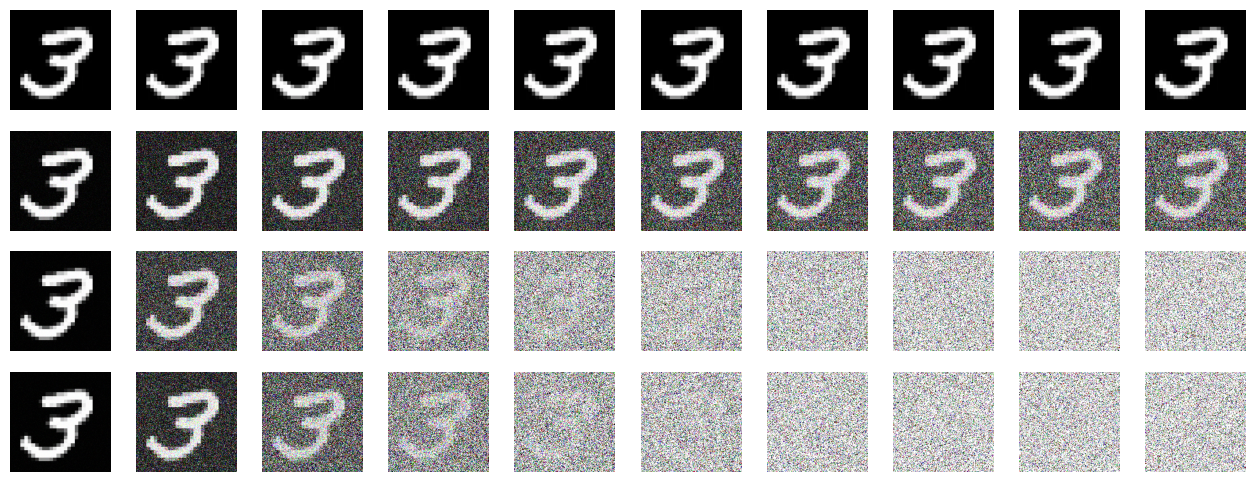

In [6]:
fig, axes = plt.subplots(4, 10, figsize=(16, 6))

for i in range(10):
    img = image_tensor.detach().cpu()
    img = img.permute(1, 2, 0)  
    axes[0][i].imshow(img)
    axes[0][i].axis('off')

img2 = image_tensor
img2 = img2.permute(1, 2, 0)  
for i in range(10):
    img2 = add_noise(img2)
    img2 = img2.detach().cpu()
    axes[1][i].imshow(img2)
    axes[1][i].axis('off')
    for j in range(100):
        img2 = add_noise(img2)


img3 = image_tensor
img3 = img3.permute(1, 2, 0) 
for i in range(10):
    img3 = add_noise_formula(img3, i*100)
    img3 = img3.detach().cpu()
    axes[2][i].imshow(img3)
    axes[2][i].axis('off')
    for j in range(100):
        img3 = add_noise_formula(img3, i*100 + j)
    
img4 = image_tensor
for i in range(10):
    img4 = get_noisy_image_instant(img4, i*100)
    axes[3][i].imshow(img4.detach().cpu().squeeze().permute(1, 2, 0))
    axes[3][i].axis('off')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94317394..1.9368896].


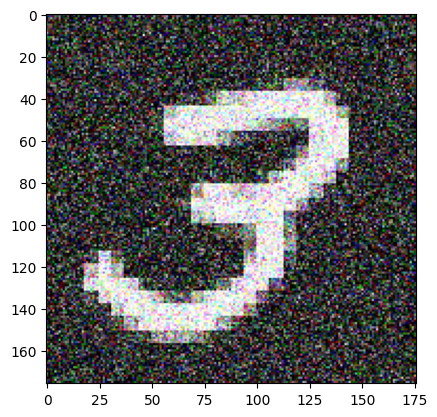

In [7]:
img = image_tensor.permute((1,2,0))
img = get_noisy_image_instant(img, 99)
plt.imshow(img.squeeze())

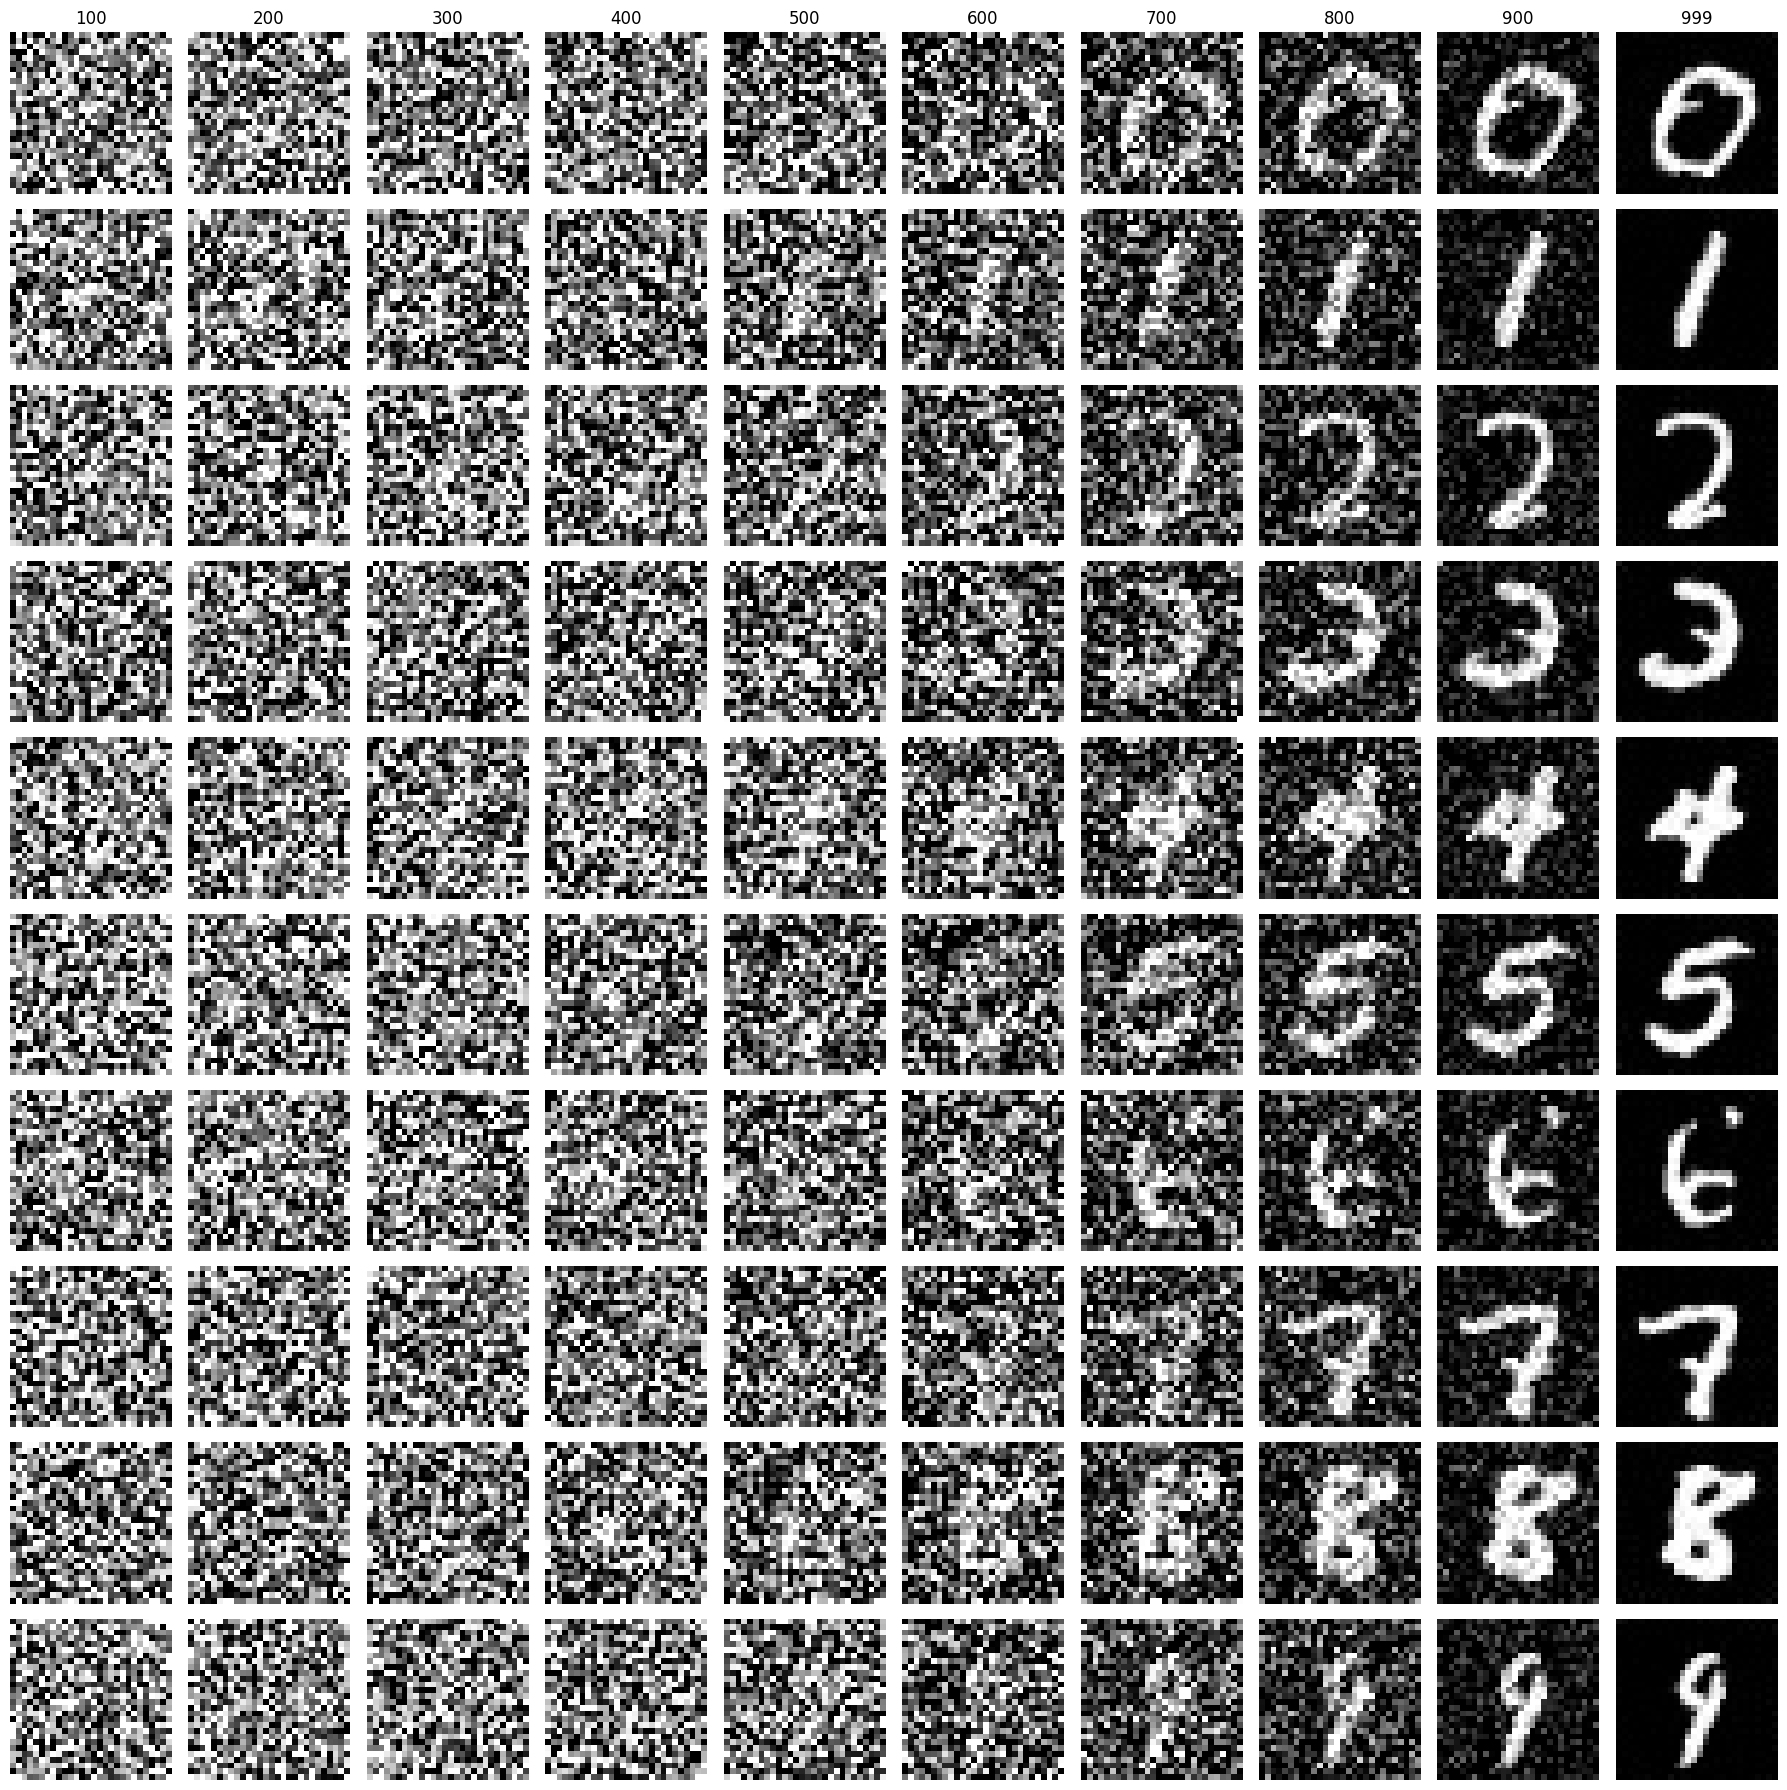

In [8]:
import torch
import matplotlib.pyplot as plt
from Model_architecture.DDPM_unnet_attntion import DDPM_model

# ----------------------------------------------------
# Config
# ----------------------------------------------------
class Config:
    T = 1000
    num_classes = 10
    image_size = 28
    in_channels = 1
    hidden_channels = 64

device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------------------------------
# Load model
# ----------------------------------------------------
config = Config()

model = DDPM_model(config).to(device)
state = torch.load("Models/attention_model_100.pt", map_location=device)
model.load_state_dict(state)
model.eval()

# ----------------------------------------------------
# Timesteps to visualize
# ----------------------------------------------------
save_steps = [900, 800, 700, 600, 500, 400, 300, 200, 100, 1]

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
fig, axes = plt.subplots(
    nrows=10,
    ncols=len(save_steps),
    figsize=(18, 18)
)

with torch.no_grad():

    for digit in range(10):

        label = torch.tensor([digit], device=device)

        # Start from Gaussian noise
        img = torch.randn(
            1,
            config.in_channels,
            config.image_size,
            config.image_size,
            device=device
        )

        saved = {}

        # Reverse diffusion
        for t in range(config.T - 1, 0, -1):

            t_tensor = torch.tensor([t], device=device)

            predicted_noise = model(img, t_tensor, label)

            beta_t = model.betas[t]
            alpha_t = model.alphas[t]
            alpha_bar_t = model.alphas_cumprod[t]

            img = (
                1 / torch.sqrt(alpha_t)
            ) * (
                img
                - (beta_t / torch.sqrt(1 - alpha_bar_t))
                * predicted_noise
            )

            if t > 1:
                img += torch.sqrt(beta_t) * torch.randn_like(img)

            if t in save_steps:
                saved[t] = img.detach().cpu()

        # Draw row
        for col, step in enumerate(save_steps):

            image = saved[step].squeeze()
            image = (image.clamp(-1, 1) + 1) / 2

            axes[digit, col].imshow(image, cmap="gray")
            axes[digit, col].axis("off")

            if digit == 0:
                axes[digit, col].set_title(f"{1000-step}", fontsize=12)

        # Label each row
        axes[digit, 0].set_ylabel(
            f"{digit}",
            rotation=0,
            labelpad=20,
            fontsize=14,
            va="center"
        )

plt.tight_layout()
plt.show()